# EDA — Reclamações Bancárias

## Objetivo
Entender a estrutura do dataset de reclamações para preparar
o pipeline de classificação de sentimentos e o sistema RAG.

## Perguntas a responder
1. Quais colunas temos? Onde está o texto da reclamação?
2. Qual a distribuição de produtos e categorias?
3. Como é o texto das reclamações — tamanho, idioma, qualidade?
4. Há dados faltantes relevantes?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [2]:
df = pd.read_csv('../data/raw/rows.csv')
print(f"Shape: {df.shape}")
print(f"\nColunas:")
for col in df.columns:
    print(f"  - {col}")

Shape: (1282355, 18)

Colunas:
  - Date received
  - Product
  - Sub-product
  - Issue
  - Sub-issue
  - Consumer complaint narrative
  - Company public response
  - Company
  - State
  - ZIP code
  - Tags
  - Consumer consent provided?
  - Submitted via
  - Date sent to company
  - Company response to consumer
  - Timely response?
  - Consumer disputed?
  - Complaint ID


C:\Users\Administrador\AppData\Local\Temp\ipykernel_24228\2942594164.py:1: DtypeWarning: Columns (4,5,6,11,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/rows.csv')


In [3]:
# Primeiras linhas para entender o conteúdo real
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964


In [5]:
# Como é o texto de uma reclamação real?
print("=== EXEMPLO DE RECLAMAÇÃO ===")
exemplo = df['Consumer complaint narrative'].dropna().iloc[0]
print(exemplo)

=== EXEMPLO DE RECLAMAÇÃO ===
The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the credit bureaus and the credit card company several times. Only the credit bureaus responded that this debt was verified but showed no proof as I requested. XXXX XXXX still has not responded to any of my letters since XX/XX/2018. All I asked was that the credit bureaus show me how they verified this debt and what XXXX XXXX sent them as proof of my debt other than a bill that could be fabricated. I really need to know why I haven't been shown proof of this after multiple disputes and certified letters letters sent.


In [10]:
print("=== VALORES ÚNICOS POR COLUNA ===")
cols = ['Consumer disputed?', 'Consumer consent provided?', 
        'Product', 'Company public response',
        'Timely response?']
for col in cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(5))

=== VALORES ÚNICOS POR COLUNA ===

Consumer disputed?:
Consumer disputed?
No     620123
Yes    148378
Name: count, dtype: int64

Consumer consent provided?:
Consumer consent provided?
Consent provided        383885
Consent not provided    285087
Other                    20482
Consent withdrawn         1200
Name: count, dtype: int64

Product:
Product
Mortgage                                                                        278098
Debt collection                                                                 244873
Credit reporting, credit repair services, or other personal consumer reports    225978
Credit reporting                                                                140432
Credit card                                                                      89190
Name: count, dtype: int64

Company public response:
Company public response
Company has responded to the consumer and the CFPB and chooses not to provide a public response    311852
Company believes it acted appro

In [11]:
mask = (
    (df['Consumer complaint narrative'].notna()) &
    (df['Consumer consent provided?'] == 'Consent provided') &
    (df['Consumer disputed?'].notna())
)

df_filtrado = df[mask].copy()

print(f"Dataset original:  {len(df):,} reclamações")
print(f"Após filtros:      {len(df_filtrado):,} reclamações")
print(f"Percentual:        {len(df_filtrado)/len(df)*100:.1f}%")

print(f"\nDistribuição do label após filtro:")
print(df_filtrado['Consumer disputed?'].value_counts())
print(f"\nProporção:")
print(df_filtrado['Consumer disputed?'].value_counts(normalize=True).round(3))

Dataset original:  1,282,355 reclamações
Após filtros:      164,076 reclamações
Percentual:        12.8%

Distribuição do label após filtro:
Consumer disputed?
No     128269
Yes     35807
Name: count, dtype: int64

Proporção:
Consumer disputed?
No     0.782
Yes    0.218
Name: proportion, dtype: float64


## 2. Análise do Texto das Reclamações

In [12]:
# Analisando características do texto
df_filtrado['text_length'] = df_filtrado['Consumer complaint narrative'].str.len()
df_filtrado['word_count'] = df_filtrado['Consumer complaint narrative'].str.split().str.len()

print("=== CARACTERÍSTICAS DO TEXTO ===")
print(f"\nComprimento em caracteres:")
print(df_filtrado['text_length'].describe().round(0))
print(f"\nNúmero de palavras:")
print(df_filtrado['word_count'].describe().round(0))

# Distribuição por label
print(f"\nMédia de palavras por label:")
print(df_filtrado.groupby('Consumer disputed?')['word_count'].mean().round(0))

=== CARACTERÍSTICAS DO TEXTO ===

Comprimento em caracteres:
count    164076.0
mean       1040.0
std         912.0
min           8.0
25%         389.0
50%         737.0
75%        1385.0
max        5151.0
Name: text_length, dtype: float64

Número de palavras:
count    164076.0
mean        191.0
std         167.0
min           1.0
25%          71.0
50%         136.0
75%         255.0
max        1284.0
Name: word_count, dtype: float64

Média de palavras por label:
Consumer disputed?
No     182.0
Yes    221.0
Name: word_count, dtype: float64


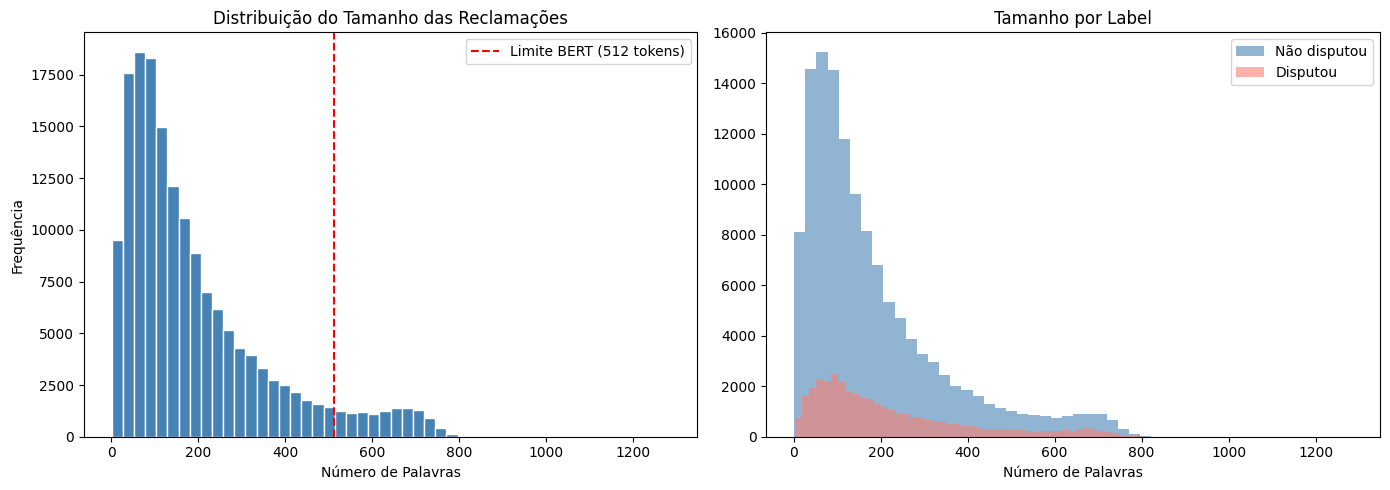

Reclamações acima do limite BERT: 7.1%


In [13]:
# Distribuição do tamanho dos textos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma geral
axes[0].hist(df_filtrado['word_count'], bins=50, 
             color='steelblue', edgecolor='white')
axes[0].axvline(x=512, color='red', linestyle='--', 
                label='Limite BERT (512 tokens)')
axes[0].set_title('Distribuição do Tamanho das Reclamações')
axes[0].set_xlabel('Número de Palavras')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Por label
axes[1].hist(df_filtrado[df_filtrado['Consumer disputed?']=='No']['word_count'],
             bins=50, alpha=0.6, label='Não disputou', color='steelblue')
axes[1].hist(df_filtrado[df_filtrado['Consumer disputed?']=='Yes']['word_count'],
             bins=50, alpha=0.6, label='Disputou', color='salmon')
axes[1].set_title('Tamanho por Label')
axes[1].set_xlabel('Número de Palavras')
axes[1].legend()

plt.tight_layout()
plt.show()

pct_acima_512 = (df_filtrado['word_count'] > 512).mean() * 100
print(f"Reclamações acima do limite BERT: {pct_acima_512:.1f}%")

## 3. Análise de Produtos e Categorias

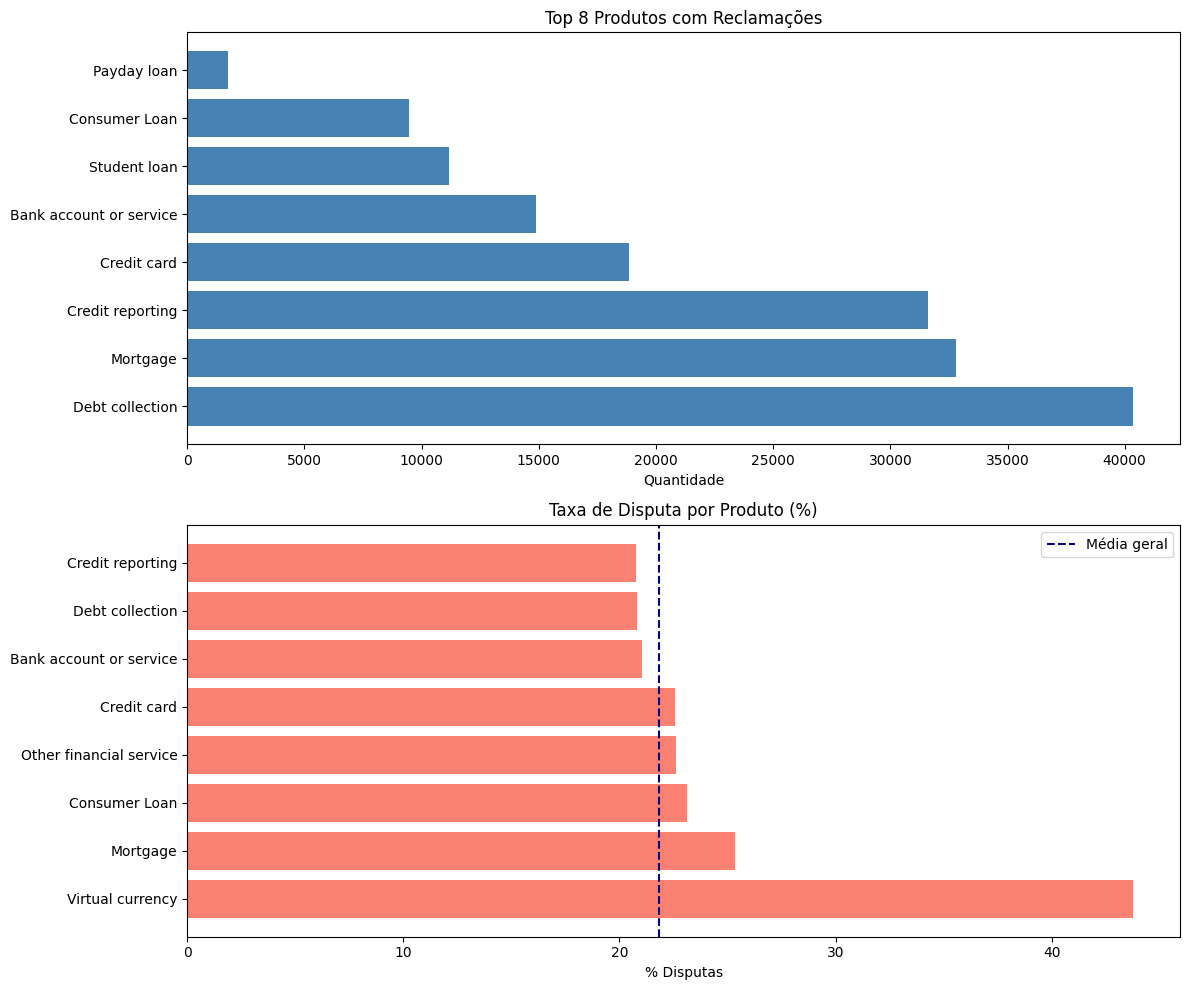

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top produtos
top_products = df_filtrado['Product'].value_counts().head(8)
axes[0].barh(top_products.index, top_products.values, color='steelblue')
axes[0].set_title('Top 8 Produtos com Reclamações')
axes[0].set_xlabel('Quantidade')

# Taxa de disputa por produto
dispute_rate = df_filtrado.groupby('Product')['Consumer disputed?'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False).head(8)

axes[1].barh(dispute_rate.index, dispute_rate.values, color='salmon')
axes[1].axvline(x=df_filtrado['Consumer disputed?'].eq('Yes').mean()*100,
                color='navy', linestyle='--', label=f'Média geral')
axes[1].set_title('Taxa de Disputa por Produto (%)')
axes[1].set_xlabel('% Disputas')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Insights Finais e Decisões para Modelagem

In [16]:
print("""
INSIGHTS DO EDA
===============

DATASET:
→ 1.28M reclamações totais
→ 164k com texto + consentimento + label (12.8%)
→ Inglês, média de 191 palavras por reclamação

LABEL (Consumer disputed?):
→ Não disputou (Positivo): 78.2%
→ Disputou (Negativo):     21.8%
→ Desbalanceamento similar ao projeto de churn

TEXTO:
→ 7.1% acima do limite BERT de 512 tokens
→ Clientes insatisfeitos escrevem 21% mais (221 vs 182 palavras)
→ Presença de XXXX como anonimização de dados sensíveis

PRODUTOS:
→ Debt Collection: maior volume de reclamações
→ Virtual Currency: maior taxa de disputa (44%)
→ Mortgage: acima da média de disputas (23%)

DECISÕES TÉCNICAS:
→ Texto: Consumer complaint narrative
→ Label: Consumer disputed? (Yes=1, No=0)
→ Truncamento: 512 tokens (limite BERT)
→ Amostragem: 10k registros para fine-tuning (5k por classe)
→ Modelo: distilbert-base-uncased (mais leve que BERT completo)
""")


INSIGHTS DO EDA

DATASET:
→ 1.28M reclamações totais
→ 164k com texto + consentimento + label (12.8%)
→ Inglês, média de 191 palavras por reclamação

LABEL (Consumer disputed?):
→ Não disputou (Positivo): 78.2%
→ Disputou (Negativo):     21.8%
→ Desbalanceamento similar ao projeto de churn

TEXTO:
→ 7.1% acima do limite BERT de 512 tokens
→ Clientes insatisfeitos escrevem 21% mais (221 vs 182 palavras)
→ Presença de XXXX como anonimização de dados sensíveis

PRODUTOS:
→ Debt Collection: maior volume de reclamações
→ Virtual Currency: maior taxa de disputa (44%)
→ Mortgage: acima da média de disputas (23%)

DECISÕES TÉCNICAS:
→ Texto: Consumer complaint narrative
→ Label: Consumer disputed? (Yes=1, No=0)
→ Truncamento: 512 tokens (limite BERT)
→ Amostragem: 10k registros para fine-tuning (5k por classe)
→ Modelo: distilbert-base-uncased (mais leve que BERT completo)

